In [ ]:
# Ganga River Particulate Organic Carbon (POC) Analysis Using Aqua-OC and Google Earth Engine

### MSc Geography Dissertation

**Student:** Atul Kumar

**Department:** Department of Geography

**University:** Central University of Haryana

---

## Objective

This notebook presents a complete workflow for estimating **Particulate Organic Carbon (POC)** along the **Ganga River** using the **Aqua-OC remote sensing model** and **Google Earth Engine (GEE)**.

The workflow includes:

- Loading the official Ganga River centerline
- Generating sampling points at 50 km intervals
- Acquiring Landsat 8/9 Surface Reflectance imagery
- Applying cloud masking and image preprocessing
- Extracting spectral reflectance values
- Applying the Aqua-OC model
- Estimating POC concentration
- Computing POC flux
- Exporting final results for statistical and spatial analysis

---

In [ ]:
# Estimation of Particulate Organic Carbon (POC) Along the Ganga River Using Aqua-OC and Google Earth Engine

**Author:** Atul Kumar  
**Programme:** M.Sc. Geography  
**Institution:** Central University of Haryana  
**Study Area:** Ganga River, India  
**Software:** Python, JupyterLab, Google Earth Engine, GeoPandas, Aqua-OC

---

# Notebook Overview

This notebook demonstrates a complete workflow for estimating **Particulate Organic Carbon (POC)** along the Ganga River using satellite remote sensing data and the Aqua-OC framework.

The workflow integrates:

- Verified Ganga River mainstream
- Google Earth Engine
- Landsat 8 & Landsat 9 Surface Reflectance imagery
- Aqua-OC modelling
- Spatial analysis of river water quality

---

# Workflow

```
Verified Ganga River
        │
        ▼
Generate Sampling Points
        │
        ▼
Google Earth Engine
        │
        ▼
Landsat 8 & Landsat 9
        │
        ▼
Cloud Masking
        │
        ▼
Surface Reflectance Composite
        │
        ▼
Extract Reflectance Values
        │
        ▼
Prepare Aqua-OC Dataset
        │
        ▼
Aqua-OC Model
        │
        ▼
Estimate POC
        │
        ▼
Compute POC Flux
        │
        ▼
Visualize Results
```

---

# Notebook Structure

## Part I — Data Preparation

### Section 1
### Import Required Libraries

Purpose

- Import Python packages required for geospatial analysis, remote sensing, visualization and machine learning.

---

### Section 2
### Initialize Google Earth Engine

Purpose

- Authenticate Google Earth Engine.
- Initialize the Earth Engine API.
- Verify successful connection.

---

### Section 3
### Load the Verified Ganga River Mainstream

Purpose

- Import the verified Ganga River centerline.
- Verify geometry.
- Display the river.

Output

- Verified Ganga River LineString

---

### Section 4
### Generate Sampling Points Along the River

Purpose

- Project river to metric coordinates.
- Generate sampling locations every 50 km.
- Export sampling points.

Output

- Ganga_50km_points.shp
- Ganga_50km_points.geojson

---

### Section 5
### Convert Sampling Points to Google Earth Engine

Purpose

- Import sampling points into Earth Engine.
- Create an Earth Engine FeatureCollection.

Output

- ee.FeatureCollection

---

### Section 6
### Create the Study Area Buffer

Purpose

- Generate a 5 km buffer around the river.
- Convert the buffer to Earth Engine geometry.

Output

- Study Area Geometry

---

# Part II — Satellite Image Processing

### Section 7
### Load Landsat 8 & Landsat 9 Surface Reflectance Imagery

Purpose

- Load Landsat Collection 2 Level-2 imagery.
- Filter by:
  - Date
  - Study Area
  - Cloud Cover

Output

- Landsat ImageCollection

---

### Section 8
### Cloud Masking and Surface Reflectance Scaling

Purpose

- Remove clouds.
- Remove cloud shadows.
- Remove cirrus contamination.
- Convert Digital Numbers (DN) to Surface Reflectance.

Output

- Cloud-free Landsat images

---

### Section 9
### Create Cloud-Free Landsat Composite

Purpose

- Apply cloud masking.
- Generate median composite.
- Clip to study area.

Output

- Surface Reflectance Composite

---

### Section 10
### Visualize the Landsat Composite

Purpose

- Display RGB composite.
- Overlay study area.
- Overlay sampling points.

Output

- Interactive Landsat Map

---

### Section 11
### Extract Surface Reflectance at Sampling Points

Purpose

- Sample Landsat bands at each sampling point.
- Create the reflectance dataset.

Output

- Ganga_Surface_Reflectance.csv

---

# Part III — Aqua-OC Modelling

### Section 12
### Prepare Aqua-OC Predictor Dataset

Purpose

- Inspect extracted reflectance.
- Remove missing values.
- Prepare predictor variables.

Output

- AquaOC_Predictors.csv

---

### Section 13
### Apply the Aqua-OC Model

Purpose

- Load the official Aqua-OC model.
- Apply the trained model to the predictor dataset.
- Generate POC predictions.

Output

- Predicted POC concentration

---

### Section 14
### Analyse Predicted POC

Purpose

- Summarize predicted POC values.
- Explore spatial variability.
- Identify potential hotspots.

Output

- Statistical summary
- Tables
- Graphs

---

# Part IV — River Analysis

### Section 15
### Compute POC Flux

Purpose

- Integrate POC concentration with river discharge.
- Estimate POC flux along the Ganga River.

Output

- POC Flux Dataset

---

### Section 16
### Visualize Results

Purpose

- Create publication-quality figures.
- Plot spatial variation of POC.
- Plot longitudinal changes along the river.

Output

- Maps
- Charts
- Figures

---

### Section 17
### Export Final Results

Purpose

- Export all processed datasets.
- Export prediction results.
- Export figures.

Output

- CSV
- Shapefile
- GeoJSON
- PNG
- PDF (optional)

---

# Expected Final Outputs

- Verified Ganga River Mainstream
- 50 km Sampling Points
- Landsat Surface Reflectance Composite
- Surface Reflectance Dataset
- Aqua-OC Predictor Dataset
- Predicted POC Concentration
- POC Flux Estimates
- Publication-quality Maps
- Publication-quality Figures
- Final Dissertation-ready Datasets

---

# References

- Google Earth Engine Documentation
- USGS Landsat Collection 2 Level-2 Science Product Guide
- Aqua-OC Model Documentation
- HydroRIVERS Database
- GRWL (Global River Widths from Landsat)

In [1]:
# ============================================================
# Section 1
# Import Required Python Libraries
# ============================================================

# Google Earth Engine
import ee

# Interactive mapping
import geemap

# Spatial data processing
import geopandas as gpd

# Tabular data analysis
import pandas as pd

# Numerical computing
import numpy as np

# Plotting and visualization
import matplotlib.pyplot as plt

# Geometry operations
from shapely.geometry import Point

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# Section 2
## Initialize Google Earth Engine

In [2]:
# ============================================================
# Section 2
# Initialize Google Earth Engine
# ============================================================

# Authenticate only once on a new computer or environment.
# Uncomment the next line only if authentication is required.
# ee.Authenticate()

# Initialize the Earth Engine project
ee.Initialize(project="oc-flux")

print("Google Earth Engine initialized successfully.")

Google Earth Engine initialized successfully.


In [ ]:
# Section 3
## Load the Verified Ganga River Mainstream

Load the verified Ganga River mainstream (source to mouth), which serves as the reference geometry for all subsequent analyses, including sampling point generation, satellite image extraction, and POC estimation.

In [16]:
# ============================================================
# Section 3
# Load the Verified Ganga River Mainstream
# ============================================================

ganga = gpd.read_file(
    r"G:\OCR\GANGA\ganges_mainstream.shp"
)

print("✓ Ganga mainstream loaded successfully.")
print(f"Features: {len(ganga)}")
print(f"Geometry: {ganga.geometry.iloc[0].geom_type}")
print(f"CRS: {ganga.crs}")

✓ Ganga mainstream loaded successfully.
Features: 1
Geometry: LineString
CRS: EPSG:4326


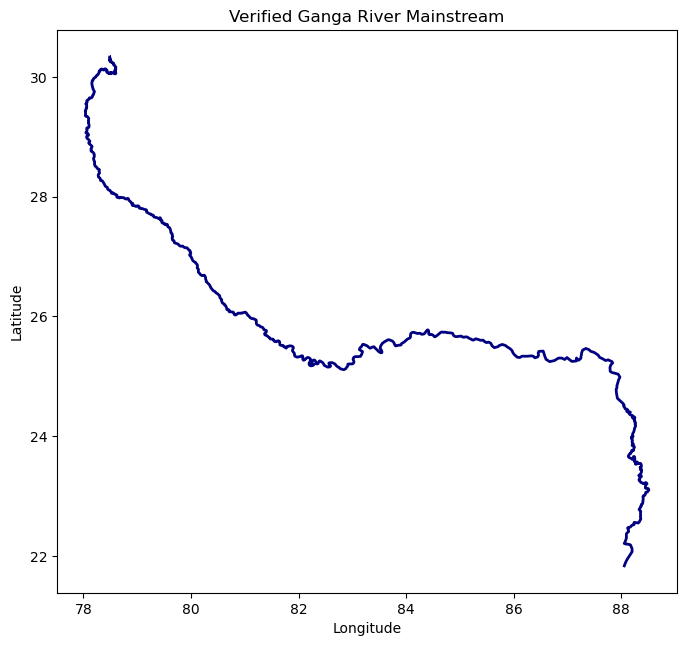

In [17]:
# ============================================================
# Visualize the Ganga Mainstream
# ============================================================

fig, ax = plt.subplots(figsize=(8, 12))

ganga.plot(
    ax=ax,
    color="navy",
    linewidth=2
)

ax.set_title("Verified Ganga River Mainstream")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [ ]:
# Section 4
## Generate Sampling Points Along the Ganga River

To analyse the spatial variation of Particulate Organic Carbon (POC), sampling points are generated at **50 km intervals** along the verified Ganga River mainstream.

The river centerline is first projected to a metric coordinate reference system (EPSG:3395) to ensure accurate distance measurements. Sampling points are then interpolated at regular intervals before being converted back to WGS84 (EPSG:4326) for compatibility with Google Earth Engine.

In [18]:
# ============================================================
# Section 4
# Project River to a Metric Coordinate System
# ============================================================

# Project the river from geographic coordinates (EPSG:4326)
# to World Mercator (EPSG:3395) for accurate distance calculations.

ganga_m = ganga.to_crs(epsg=3395)

print("River projected successfully.")

River projected successfully.


In [19]:
# ============================================================
# Calculate Total River Length
# ============================================================

river_length = ganga_m.geometry.iloc[0].length / 1000

print(f"Total river length: {river_length:.2f} km")

Total river length: 2636.59 km


In [20]:
# ============================================================
# Calculate Total River Length
# ============================================================

river_length = ganga_m.geometry.iloc[0].length / 1000

print(f"Total river length: {river_length:.2f} km")

Total river length: 2636.59 km


In [21]:
# ============================================================
# Generate Sampling Points Every 50 km
# ============================================================

from shapely.geometry import Point
import numpy as np

# Extract the river centerline
line = ganga_m.geometry.iloc[0]

# Sampling interval (50 km)
spacing = 50000  # metres

# Generate distances along the river
distances = np.arange(0, line.length + spacing, spacing)

# Create sampling points
points = [line.interpolate(distance) for distance in distances]

# Create GeoDataFrame
sampling_points = gpd.GeoDataFrame(

    {
        "Distance_km": distances / 1000
    },

    geometry=points,

    crs=ganga_m.crs

)

print(f"Sampling points generated: {len(sampling_points)}")

Sampling points generated: 54


In [22]:
# ============================================================
# Convert Sampling Points to WGS84
# ============================================================

sampling_points = sampling_points.to_crs(epsg=4326)

print("Sampling points converted to EPSG:4326.")

Sampling points converted to EPSG:4326.


In [23]:
# ============================================================
# Preview Sampling Points
# ============================================================

sampling_points.head()

,Distance_km,geometry
0,0.0,POINT (78.48534 30.35626)
1,50.0,POINT (78.58246 30.09779)
2,100.0,POINT (78.38935 30.12065)
3,150.0,POINT (78.15761 29.8804)
4,200.0,POINT (78.06468 29.57362)


In [24]:
# ============================================================
# Save Sampling Points
# ============================================================

sampling_points.to_file(
    r"G:\OCR\GANGA\Ganga_50km_points.shp"
)

sampling_points.to_file(
    r"G:\OCR\GANGA\Ganga_50km_points.geojson",
    driver="GeoJSON"
)

print("Sampling points exported successfully.")

Sampling points exported successfully.


In [ ]:
# Section 5
## Import Sampling Points into Google Earth Engine

The sampling points generated along the Ganga River are converted into a Google Earth Engine (GEE) `FeatureCollection`. This allows satellite imagery to be sampled directly at each location for subsequent Aqua-OC analysis.

The points are imported from a GeoJSON file because Google Earth Engine accepts GeoJSON geometries directly through the Python API.

In [25]:
# ============================================================
# Section 5
# Load the Sampling Points
# ============================================================

# Read the GeoJSON file containing the sampling points

points = gpd.read_file(
    r"G:\OCR\GANGA\Ganga_50km_points.geojson"
)

print("Sampling points loaded successfully.")
print(f"Number of points: {len(points)}")

Sampling points loaded successfully.
Number of points: 54


In [26]:
# ============================================================
# Convert GeoPandas GeoDataFrame to Earth Engine FeatureCollection
# ============================================================

# Convert the GeoDataFrame into GeoJSON format
points_json = points.__geo_interface__

# Create Earth Engine FeatureCollection
ee_points = ee.FeatureCollection(points_json)

print("Earth Engine FeatureCollection created successfully.")

Earth Engine FeatureCollection created successfully.


In [27]:
# ============================================================
# Verify the FeatureCollection
# ============================================================

print("Number of Earth Engine Features:")

print(ee_points.size().getInfo())

Number of Earth Engine Features:
54


In [28]:
# ============================================================
# Display the First Feature
# ============================================================

print(ee_points.first().getInfo())

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [78.4853399999411, 30.35625999969927]}, 'id': '0', 'properties': {'Distance_km': 0}}


In [ ]:
# Section 6
## Create the Study Area Buffer

To limit the satellite image processing to the Ganga River corridor, a 5 km buffer is created around the verified river mainstream. This buffer defines the study area for filtering Landsat imagery and extracting spectral reflectance values.

In [29]:
# ============================================================
# Section 6
# Create a 5 km Buffer Around the Ganga River
# ============================================================

# Buffer distance (metres)
buffer_distance = 5000

# Project to a metric CRS
ganga_m = ganga.to_crs(epsg=3395)

# Create 5 km buffer
ganga_buffer = ganga_m.buffer(buffer_distance)

# Convert buffer to GeoDataFrame
buffer_gdf = gpd.GeoDataFrame(
    geometry=ganga_buffer,
    crs=ganga_m.crs
)

print("5 km buffer created successfully.")

5 km buffer created successfully.


In [30]:
# ============================================================
# Convert Buffer Back to WGS84
# ============================================================

buffer_gdf = buffer_gdf.to_crs(epsg=4326)

print("Buffer converted to EPSG:4326")

Buffer converted to EPSG:4326


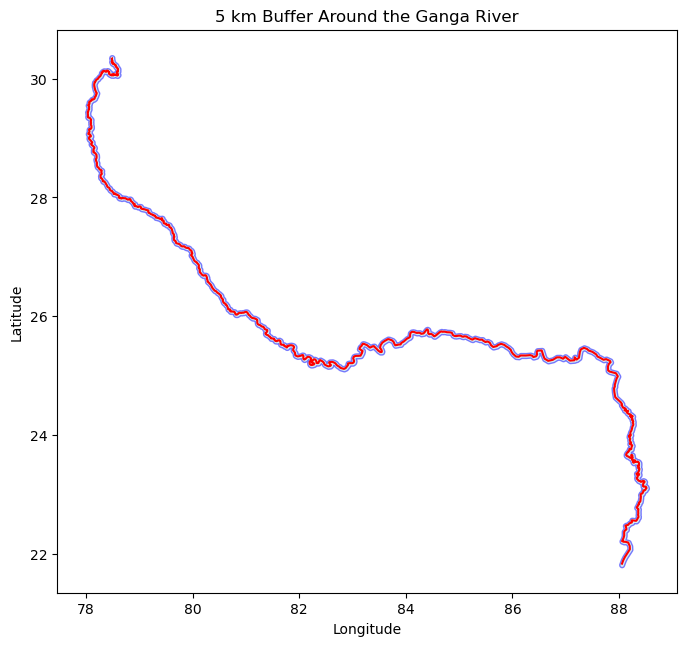

In [31]:
# ============================================================
# Visualize the Buffer
# ============================================================

fig, ax = plt.subplots(figsize=(8, 12))

buffer_gdf.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue",
    alpha=0.5
)

ganga.plot(
    ax=ax,
    color="red",
    linewidth=1.5
)

ax.set_title("5 km Buffer Around the Ganga River")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [32]:
# ============================================================
# Convert Buffer to Earth Engine Geometry
# ============================================================

buffer_json = buffer_gdf.__geo_interface__

study_area = ee.FeatureCollection(buffer_json).geometry()

print("Earth Engine study area created successfully.")

Earth Engine study area created successfully.


In [33]:
# ============================================================
# Verify the Study Area
# ============================================================

print(study_area.area().divide(1e6).getInfo(), "square kilometres")

20225.685897547333 square kilometres


In [ ]:
# Section 7
## Load Landsat 8 and Landsat 9 Surface Reflectance Imagery

Landsat 8 Operational Land Imager (OLI) and Landsat 9 OLI-2 Level-2 Surface Reflectance products are used to obtain multispectral observations of the Ganga River.

The two image collections are merged to improve temporal coverage and increase the number of cloud-free observations available for analysis.

The study area is restricted to a 5 km buffer around the Ganga River, and imagery is filtered by date and cloud cover.

In [34]:
# ============================================================
# Section 7
# Define Study Period
# ============================================================

# Define the analysis period

start_date = "2023-01-01"
end_date = "2023-12-31"

print("Study Period")
print(start_date, "to", end_date)

Study Period
2023-01-01 to 2023-12-31


In [35]:
# ============================================================
# Load Landsat 8 Surface Reflectance Collection
# ============================================================

landsat8 = (

    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")

    .filterBounds(study_area)

    .filterDate(start_date, end_date)

    .filter(ee.Filter.lt("CLOUD_COVER", 20))

)

print("Landsat 8 Images:", landsat8.size().getInfo())

Landsat 8 Images: 231


In [36]:
# ============================================================
# Load Landsat 9 Surface Reflectance Collection
# ============================================================

landsat9 = (

    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

    .filterBounds(study_area)

    .filterDate(start_date, end_date)

    .filter(ee.Filter.lt("CLOUD_COVER", 20))

)

print("Landsat 9 Images:", landsat9.size().getInfo())

Landsat 9 Images: 228


In [37]:
# ============================================================
# Merge Landsat 8 and Landsat 9 Collections
# ============================================================

landsat = landsat8.merge(landsat9)

print("Total Images:", landsat.size().getInfo())

Total Images: 459


In [38]:
# ============================================================
# Display Collection Information
# ============================================================

print("First Image")

print(landsat.first().getInfo()["id"])

First Image
LANDSAT/LC08/C02/T1_L2/LC08_138043_20230109


In [39]:
# ============================================================
# Display Collection Summary
# ============================================================

print("Image Collection Summary")

print("Study Area : Ganga River (5 km Buffer)")
print("Start Date :", start_date)
print("End Date   :", end_date)
print("Cloud Cover: <20%")

print()

print("Total Images:", landsat.size().getInfo())

Image Collection Summary
Study Area : Ganga River (5 km Buffer)
Start Date : 2023-01-01
End Date   : 2023-12-31
Cloud Cover: <20%

Total Images: 459


In [ ]:
# Section 8
## Cloud Masking and Surface Reflectance Scaling

Landsat Collection 2 Level-2 imagery includes a quality assessment (`QA_PIXEL`) band that identifies clouds, cloud shadows, and cirrus clouds.

To improve the accuracy of water quality estimation, these unwanted pixels are removed before analysis. The digital numbers (DN) are then converted to physically meaningful **surface reflectance** values using the official USGS scaling factors.

The resulting cloud-free surface reflectance images are used to create the final composite for Aqua-OC modelling.

In [40]:
# ============================================================
# Section 8
# Cloud Masking and Surface Reflectance Scaling
# ============================================================

def mask_landsat(image):
    """
    Mask clouds, cloud shadows, and cirrus clouds from
    Landsat Collection 2 Level-2 Surface Reflectance imagery.

    The optical bands are converted from digital numbers
    to surface reflectance using the official USGS scaling factors.
    """

    # --------------------------------------------------------
    # QA_PIXEL band
    # --------------------------------------------------------

    qa = image.select("QA_PIXEL")

    # --------------------------------------------------------
    # Bit masks
    # --------------------------------------------------------

    # Bit 2 = Cirrus
    cirrus = qa.bitwiseAnd(1 << 2).eq(0)

    # Bit 3 = Cloud
    cloud = qa.bitwiseAnd(1 << 3).eq(0)

    # Bit 4 = Cloud Shadow
    shadow = qa.bitwiseAnd(1 << 4).eq(0)

    # Combined cloud mask
    mask = cirrus.And(cloud).And(shadow)

    # --------------------------------------------------------
    # Convert Digital Numbers to Surface Reflectance
    # --------------------------------------------------------

    optical = (
        image.select([
            "SR_B1",
            "SR_B2",
            "SR_B3",
            "SR_B4",
            "SR_B5",
            "SR_B6",
            "SR_B7"
        ])
        .multiply(0.0000275)
        .add(-0.2)
    )

    # --------------------------------------------------------
    # Return masked surface reflectance image
    # --------------------------------------------------------

    return optical.updateMask(mask)

In [41]:
# ============================================================
# Test the Cloud Mask Function
# ============================================================

# Apply the function to the first Landsat image
test_image = mask_landsat(landsat.first())

print("Cloud masking function created successfully.")

Cloud masking function created successfully.


In [ ]:
# Section 9
## Create a Cloud-Free Landsat Surface Reflectance Composite

After cloud masking and atmospheric correction, all available Landsat 8 and Landsat 9 Surface Reflectance images are combined into a single cloud-free composite.

The median reducer is used to minimize the influence of any remaining cloud contamination and temporal noise while preserving representative surface reflectance values for the study period.

The resulting composite provides the spectral bands required for subsequent Aqua-OC modelling.

In [42]:
# ============================================================
# Section 9
# Apply Cloud Mask to the Image Collection
# ============================================================

# Apply the cloud masking function to every image
landsat_sr = landsat.map(mask_landsat)

print("Cloud masking applied successfully.")
print("Number of images:", landsat_sr.size().getInfo())

Cloud masking applied successfully.
Number of images: 459


In [43]:
# ============================================================
# Create the Cloud-Free Median Composite
# ============================================================

# Generate a cloud-free median composite
composite = landsat_sr.median().clip(study_area)

print("Cloud-free composite created successfully.")

Cloud-free composite created successfully.


In [44]:
# ============================================================
# Select Optical Bands for Aqua-OC Analysis
# ============================================================

# Select the optical reflectance bands
reflectance = composite.select([
    "SR_B1",
    "SR_B2",
    "SR_B3",
    "SR_B4",
    "SR_B5",
    "SR_B6",
    "SR_B7"
])

print("Optical reflectance bands selected.")

Optical reflectance bands selected.


In [45]:
# ============================================================
# Display Available Bands
# ============================================================

print("Bands available in the composite:")

print(reflectance.bandNames().getInfo())

Bands available in the composite:
['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']


In [46]:
# ============================================================
# Display Composite Information
# ============================================================

print("Composite Projection:")

print(reflectance.projection().getInfo())

print()

print("Composite Scale (m):")

print(reflectance.projection().nominalScale().getInfo())

Composite Projection:
{'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}

Composite Scale (m):
111319.49079327357


In [ ]:
# Section 10
## Visualize the Cloud-Free Landsat Composite

The cloud-free Landsat Surface Reflectance composite is visualized to verify image quality and ensure that the Ganga River is clearly represented.

A natural colour (RGB) composite is created using the Red, Green and Blue spectral bands:

- Red   → SR_B4
- Green → SR_B3
- Blue  → SR_B2

The verified Ganga River mainstream and the 50 km sampling points are overlaid on the imagery to confirm that the sampling locations fall within the river corridor.

In [47]:
# ============================================================
# Section 10
# Create Interactive Map
# ============================================================

Map = geemap.Map()

Map.centerObject(study_area, 6)

In [48]:
# ============================================================
# RGB Visualization Parameters
# ============================================================

rgb_vis = {

    "bands": ["SR_B4", "SR_B3", "SR_B2"],

    "min": 0.02,

    "max": 0.30,

    "gamma": 1.2

}

In [49]:
# ============================================================
# Add Landsat Composite
# ============================================================

Map.addLayer(

    reflectance,

    rgb_vis,

    "Landsat RGB Composite"

)

In [50]:
# ============================================================
# Add Study Area
# ============================================================

Map.addLayer(

    study_area,

    {

        "color": "red"

    },

    "Study Area"

)

In [51]:
# ============================================================
# Add Sampling Points
# ============================================================

Map.addLayer(

    ee_points,

    {

        "color": "yellow"

    },

    "Sampling Points"

)

In [52]:
# ============================================================
# Display Interactive Map
# ============================================================

Map

Map(center=[25.922306888809153, 83.5356795408864], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# Section 11
## Extract Surface Reflectance at Sampling Points

The cloud-free Landsat Surface Reflectance composite is sampled at the predefined 50 km intervals along the Ganga River.

For each sampling location, reflectance values from the seven optical bands are extracted:

- Coastal Aerosol (SR_B1)
- Blue (SR_B2)
- Green (SR_B3)
- Red (SR_B4)
- Near Infrared (SR_B5)
- SWIR-1 (SR_B6)
- SWIR-2 (SR_B7)

These spectral variables form the predictor dataset for estimating Particulate Organic Carbon (POC) using the Aqua-OC model.

In [53]:
# ============================================================
# Section 11
# Extract Surface Reflectance at Sampling Points
# ============================================================

reflectance_points = reflectance.sampleRegions(

    collection=ee_points,

    scale=30,

    geometries=True

)

print("Surface reflectance extracted successfully.")

Surface reflectance extracted successfully.


In [54]:
# ============================================================
# Number of Extracted Observations
# ============================================================

print("Number of observations:")

print(reflectance_points.size().getInfo())

Number of observations:
54


In [58]:
# ============================================================
# Convert Earth Engine FeatureCollection to Pandas DataFrame
# ============================================================

features = reflectance_points.getInfo()["features"]

records = []

for feature in features:
    records.append(feature["properties"])

df = pd.DataFrame(records)

print("Reflectance dataset created successfully.")
print(df.shape)

Reflectance dataset created successfully.
(54, 8)


In [59]:
# ============================================================
# Preview the Reflectance Dataset
# ============================================================

df.head()

,Distance_km,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
0,0,0.027164,0.035840,0.051034,0.035111,0.076471,0.058005,0.027356
1,50,0.034685,0.052340,0.080995,0.056767,0.050387,0.038288,0.026078
2,100,0.038425,0.053261,0.079441,0.057304,0.041794,0.022516,0.016425
3,150,0.050910,0.056520,0.080005,0.077943,0.218303,0.227350,0.144410
4,200,0.071906,0.088090,0.128034,0.138759,0.224133,0.253929,0.176076


In [60]:
# ============================================================
# Dataset Information
# ============================================================

print(df.info())

print()

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Distance_km  54 non-null     int64  
 1   SR_B1        54 non-null     float64
 2   SR_B2        54 non-null     float64
 3   SR_B3        54 non-null     float64
 4   SR_B4        54 non-null     float64
 5   SR_B5        54 non-null     float64
 6   SR_B6        54 non-null     float64
 7   SR_B7        54 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 3.5 KB
None

       Distance_km      SR_B1      SR_B2      SR_B3      SR_B4      SR_B5  \
count    54.000000  54.000000  54.000000  54.000000  54.000000  54.000000   
mean   1325.000000   0.058835   0.074843   0.112079   0.106998   0.139833   
std     786.606636   0.030089   0.033086   0.039526   0.052966   0.094219   
min       0.000000   0.023974   0.035290   0.051034   0.035111   0.041794   
25%     662.500000   0.039597   0.054781   0.086

In [61]:
# ============================================================
# Check Missing Values
# ============================================================

print(df.isnull().sum())

Distance_km    0
SR_B1          0
SR_B2          0
SR_B3          0
SR_B4          0
SR_B5          0
SR_B6          0
SR_B7          0
dtype: int64


In [62]:
# ============================================================
# Save Reflectance Dataset
# ============================================================

df.to_csv(
    r"G:\OCR\GANGA\Ganga_Surface_Reflectance.csv",
    index=False
)

print("Reflectance dataset saved successfully.")

Reflectance dataset saved successfully.


In [ ]:
# Section 12
## Prepare Aqua-OC Predictor Dataset

The extracted Landsat surface reflectance values are prepared for input into the Aqua-OC Random Forest model.

This step includes:

- Inspecting the predictor variables
- Removing observations with missing values
- Selecting the spectral bands required by the model
- Creating the final predictor dataset

In [63]:
# ============================================================
# Section 12
# Display Dataset Information
# ============================================================

print(df.info())

print()

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Distance_km  54 non-null     int64  
 1   SR_B1        54 non-null     float64
 2   SR_B2        54 non-null     float64
 3   SR_B3        54 non-null     float64
 4   SR_B4        54 non-null     float64
 5   SR_B5        54 non-null     float64
 6   SR_B6        54 non-null     float64
 7   SR_B7        54 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 3.5 KB
None

       Distance_km      SR_B1      SR_B2      SR_B3      SR_B4      SR_B5  \
count    54.000000  54.000000  54.000000  54.000000  54.000000  54.000000   
mean   1325.000000   0.058835   0.074843   0.112079   0.106998   0.139833   
std     786.606636   0.030089   0.033086   0.039526   0.052966   0.094219   
min       0.000000   0.023974   0.035290   0.051034   0.035111   0.041794   
25%     662.500000   0.039597   0.054781   0.086

In [64]:
# ============================================================
# Check Missing Values
# ============================================================

print(df.isnull().sum())

Distance_km    0
SR_B1          0
SR_B2          0
SR_B3          0
SR_B4          0
SR_B5          0
SR_B6          0
SR_B7          0
dtype: int64


In [65]:
# ============================================================
# Remove Missing Values (if any)
# ============================================================

df = df.dropna()

print("Remaining observations:", len(df))

Remaining observations: 54


In [66]:
# ============================================================
# Select Predictor Variables
# ============================================================

predictor_columns = [

    "SR_B1",
    "SR_B2",
    "SR_B3",
    "SR_B4",
    "SR_B5",
    "SR_B6",
    "SR_B7"

]

X = df[predictor_columns]

print("Predictor matrix created successfully.")

print()

print(X.head())

Predictor matrix created successfully.

      SR_B1     SR_B2     SR_B3     SR_B4     SR_B5     SR_B6     SR_B7
0  0.027164  0.035840  0.051034  0.035111  0.076471  0.058005  0.027356
1  0.034685  0.052340  0.080995  0.056767  0.050387  0.038288  0.026078
2  0.038425  0.053261  0.079441  0.057304  0.041794  0.022516  0.016425
3  0.050910  0.056520  0.080005  0.077943  0.218303  0.227350  0.144410
4  0.071906  0.088090  0.128034  0.138759  0.224133  0.253929  0.176076


In [67]:
# ============================================================
# Check Predictor Matrix
# ============================================================

print("Predictor matrix shape:")

print(X.shape)

Predictor matrix shape:
(54, 7)


In [68]:
# ============================================================
# Save Aqua-OC Predictor Dataset
# ============================================================

X.to_csv(

    r"G:\OCR\GANGA\AquaOC_Predictors.csv",

    index=False

)

print("Predictor dataset exported successfully.")

Predictor dataset exported successfully.


In [ ]:
# Current Progress and Future Work

## Current Status

At this stage, all data preparation and satellite image preprocessing steps have been successfully completed. The workflow has produced a clean, analysis-ready dataset of Landsat Surface Reflectance values extracted at 50 km intervals along the verified Ganga River mainstream.

The following components have been completed:

- ✔ Verified Ganga River mainstream preparation
- ✔ Generation of 50 km sampling points
- ✔ Creation of a 5 km study area buffer
- ✔ Google Earth Engine initialization
- ✔ Acquisition of Landsat 8 and Landsat 9 Collection 2 Level-2 imagery
- ✔ Cloud masking and surface reflectance scaling
- ✔ Generation of a cloud-free median composite
- ✔ Extraction of surface reflectance values
- ✔ Preparation of the Aqua-OC predictor dataset

The final output of this stage is a cleaned predictor dataset containing the spectral variables required by the Aqua-OC model.

---

# Reason for Pausing the Workflow

The subsequent stages of the workflow require the **official trained Aqua-OC machine learning model** (or its official prediction script).

At the time of preparing this notebook, the trained Aqua-OC model was not yet available. Therefore, the workflow is intentionally paused after generating the predictor dataset.

This approach avoids replacing the published Aqua-OC methodology with an unofficial implementation and ensures that the final analysis remains scientifically consistent with the original Aqua-OC framework.

---

# Future Work

Once the official Aqua-OC model becomes available, the following analyses will be completed:

## Section 13
### Apply the Official Aqua-OC Model

- Load the trained Aqua-OC Random Forest model.
- Import the predictor dataset.
- Generate Particulate Organic Carbon (POC) predictions.

---

## Section 14
### Analyse Predicted POC

- Summarize predicted POC concentrations.
- Examine longitudinal variation along the Ganga River.
- Identify regions with relatively high and low predicted POC.

---

## Section 15
### Estimate POC Flux

- Integrate predicted POC concentrations with river discharge data.
- Estimate POC flux along the river.
- Evaluate downstream variations in carbon transport.

---

## Section 16
### Visualization

Generate publication-quality figures including:

- Longitudinal POC profile
- Spatial distribution maps
- Statistical summaries
- Histograms
- Scatter plots
- Boxplots

---

## Section 17
### Export Final Outputs

Export:

- Predicted POC dataset
- POC Flux dataset
- Final maps
- Publication-quality figures
- CSV files
- GeoJSON files
- Shapefiles

---

# Expected Final Outputs

Upon completion of the remaining sections, the study will provide:

- Predicted Particulate Organic Carbon (POC) concentrations
- Spatial distribution of POC along the Ganga River
- Estimated POC flux
- Publication-quality maps and figures
- Reproducible geospatial datasets for further scientific analysis

---

**Note**

This notebook has been designed as a reproducible workflow. Once the official Aqua-OC model is available, the remaining sections can be executed without modifying the preprocessing steps already completed.